In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv('../datasets/pima-indians-diabetes.csv', names=columns)
df.head()
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=1)
x_train.shape


(614, 8)

0.7792207792207793
[[89 10]
 [24 31]]
              precision    recall  f1-score   support

          정상       0.79      0.90      0.84        99
          당뇨       0.76      0.56      0.65        55

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154



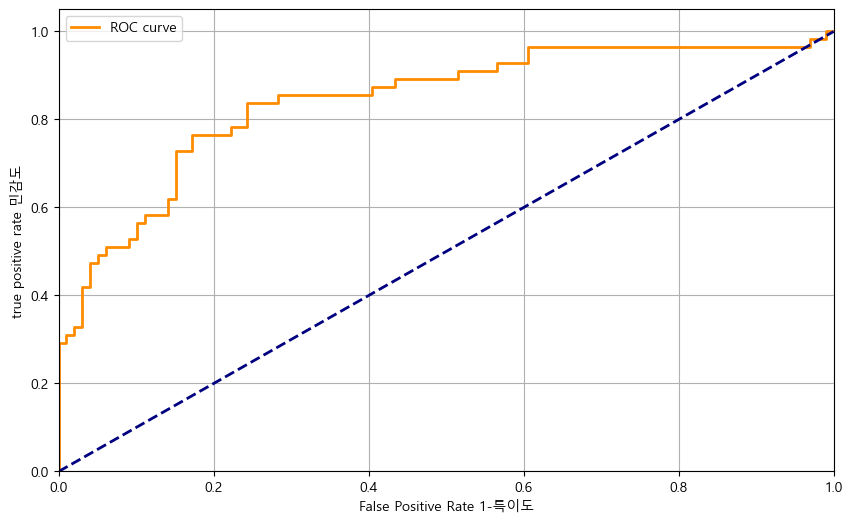

In [24]:


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from sklearn.metrics import accuracy_score
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(acc)
cm = confusion_matrix(y_test, y_pred) #혼동행렬
print(cm)
print(classification_report(y_test, y_pred, target_names=['정상','당뇨']))
y_pred_proba = model.predict_proba(x_test_scaled)[:,1] # 양성클래스
import matplotlib.pyplot as plt
from matplotlib import rc
#한글
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate 1-특이도')
plt.ylabel('true positive rate 민감도')
plt.legend()
plt.grid(True)
plt.show()



In [20]:
x_train_scaled

array([[ 1.51659096,  0.75052361,  0.56475624, ...,  0.79582546,
         0.52952571,  0.56793202],
       [ 1.81201827,  0.24475163, -0.34790438, ...,  1.22865369,
        -0.06968859,  0.39844951],
       [ 0.92573636, -0.60873859,  0.26053603, ...,  0.70401341,
        -0.79424873,  0.99163829],
       ...,
       [ 2.69830017,  0.14991938,  1.07178992, ...,  1.51720584,
         0.36443605,  0.73741453],
       [ 0.03945446,  1.57240307,  0.1591293 , ...,  1.54343785,
         0.04648561, -0.61844554],
       [ 1.51659096, -0.60873859,  0.36194277, ...,  0.14002512,
         0.61512775,  1.07637954]], shape=(614, 8))